# Elasticity Model Comparison & Rolling Validation

This notebook evaluates multiple regression models for estimating price elasticity and predicting weekly sales demand. We compare linear models, regularized models, robust regression, kernel-based Support Vector Regression, ensemble methods (Random Forest and Gradient Boosting), and Neural Networks (MLP Regressor), both with and without time-decay weights.

## Backtest Methodology
* **Training Window**: 200 weeks (rolling window of the most recent 200 weeks of historical data).
* **Test Target**: The next week immediately following the training window.
* **Rolling Step**: 1 week (we roll the window forward, re-train on the new 200-week slice, and predict the next week).
* **Key Output Metrics**: MAE, MAPE, WMAPE, RMSE, average estimated Elasticity, and parameter volatility.

## Model Ranking Weights
* **Prediction Accuracy (50% weight)**: Combined MAPE (25% weight) and WMAPE (25% weight) (lower error is better)
* **Elasticity Plausibility (30% weight)**: 1.0 for elasticity in [-2.5, -0.8], 0.5 for [-4.0, -2.5) or (-0.8, -0.4], 0.0 otherwise
* **Elasticity Stability (20% weight)**: Volatility of elasticity over rolling windows (lower Std is better)

In [80]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [81]:
# ==========================================================================
# CONFIGURATION VARIABLE
# ==========================================================================
RUN_DECAY_ONLY = False  # Set to True to evaluate only decay-based models, or False to run all 14 models
# ==========================================================================

# Load the weekly aggregated dataset
df = pd.read_csv('/Users/atishayjain/PycharmProjects/PwC/PriceAnalysis/mod_test/sales_demand_imputed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Loaded {len(df)} weeks of sales demand data. RUN_DECAY_ONLY = {RUN_DECAY_ONLY}")
df.head()

Loaded 495 weeks of sales demand data. RUN_DECAY_ONLY = False


,date,sku_id,unit_price,units_sold,cost_per_unit
0,2008-01-05,IND_BASMATI_001,33.740,1.146e+06,25.305
1,2008-01-12,IND_BASMATI_001,34.908,586000.000,26.181
2,2008-01-19,IND_BASMATI_001,31.133,586000.000,23.349
3,2008-01-26,IND_BASMATI_001,29.249,586000.000,21.937
4,2008-02-02,IND_BASMATI_001,39.085,586000.000,29.314


## Model Definition Helper

We implement a generic helper function to run each model type on a training slice.

In [82]:
def run_model(model_type, train_slice, test_price, use_decay=True, decay_rate=0.9200):
    n_obs = len(train_slice)
    if use_decay:
        max_date = train_slice['date'].max()
        t_diff_weeks = (max_date - train_slice['date']).dt.days / 7.0
        weights = decay_rate ** t_diff_weeks
    else:
        weights = np.ones(n_obs)
        
    log_p = np.log(train_slice['unit_price'].values).reshape(-1, 1)
    log_q = np.log(train_slice['units_sold'].values)
    log_p_base = np.log(test_price)
    h = 1e-4
    
    if model_type == 'Linear':
        X = sm.add_constant(log_p)
        model = sm.WLS(log_q, X, weights=weights).fit()
        elasticity = model.params[1] if len(model.params) > 1 else -1.5
        pred_log_q = model.params[0] + elasticity * log_p_base
        pred_q = np.exp(pred_log_q)
        return elasticity, pred_q
        
    elif model_type == 'Ridge':
        model = Ridge(alpha=1.0)
        model.fit(log_p, log_q, sample_weight=weights)
        elasticity = model.coef_[0]
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'Huber':
        model = HuberRegressor()
        model.fit(log_p, log_q, sample_weight=weights)
        elasticity = model.coef_[0]
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'SVR':
        model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'RF':
        model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'GB':
        model = GradientBoostingRegressor(n_estimators=50, max_depth=2, random_state=42)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'MLP':
        elasticity_vals = []
        pred_q_vals = []
        np.random.seed(42)
        normalized_weights = weights / np.sum(weights)
        for i in range(3):
            if use_decay:
                indices = np.random.choice(n_obs, size=n_obs, replace=True, p=normalized_weights)
            else:
                indices = np.random.choice(n_obs, size=n_obs, replace=True)
            X_train = log_p[indices]
            y_train = log_q[indices]
            mlp = MLPRegressor(hidden_layer_sizes=(16, 8), activation='tanh', solver='lbfgs', max_iter=1000, random_state=42 + i)
            mlp.fit(X_train, y_train)
            p_plus = mlp.predict(np.array([[log_p_base + h]]))[0]
            p_minus = mlp.predict(np.array([[log_p_base - h]]))[0]
            e_i = (p_plus - p_minus) / (2 * h)
            elasticity_vals.append(e_i)
            pred_q_vals.append(np.exp(mlp.predict([[log_p_base]])[0]))
        return np.mean(elasticity_vals), np.mean(pred_q_vals)

## Rolling Backtest Loop

We run the rolling validation starting at week 200.

In [83]:
all_configs = [
    ('Linear_NoDecay', 'Linear', False),
    ('Linear_WithDecay', 'Linear', True),
    ('Ridge_NoDecay', 'Ridge', False),
    ('Ridge_WithDecay', 'Ridge', True),
    ('Huber_NoDecay', 'Huber', False),
    ('Huber_WithDecay', 'Huber', True),
    ('SVR_NoDecay', 'SVR', False),
    ('SVR_WithDecay', 'SVR', True),
    ('RF_NoDecay', 'RF', False),
    ('RF_WithDecay', 'RF', True),
    ('GB_NoDecay', 'GB', False),
    ('GB_WithDecay', 'GB', True),
    ('MLP_NoDecay', 'MLP', False),
    ('MLP_WithDecay', 'MLP', True),
]

if RUN_DECAY_ONLY:
    model_configs = [config for config in all_configs if config[2] is True]
else:
    model_configs = all_configs

train_window = 200
results = {config[0]: [] for config in model_configs}
test_indices = range(train_window, len(df))
actual_qs = []
actual_ps = []
dates = []

for idx in test_indices:
    train_slice = df.iloc[idx-train_window : idx]
    test_row = df.iloc[idx]
    
    test_price = test_row['unit_price']
    actual_q = test_row['units_sold']
    actual_qs.append(actual_q)
    actual_ps.append(test_price)
    dates.append(test_row['date'])
    
    for name, m_type, use_decay in model_configs:
        e, pred = run_model(m_type, train_slice, test_price, use_decay=use_decay)
        e = max(-10.0, min(2.0, e))
        results[name].append({'elasticity': e, 'pred': pred})

print(f"Completed rolling backtest for {len(test_indices)} test weeks. Evaluated {len(model_configs)} models.")

Completed rolling backtest for 295 test weeks. Evaluated 14 models.


## Model Ranking & Evaluation Table

We compute the error metrics (including WMAPE) and calculate the Rank Score based on the specified weights:
* **Accuracy Score (50% weight)**: Combined MAPE (25% weight) and WMAPE (25% weight)
* **Elasticity Plausibility (30% weight)**: 1.0 for elasticity in [-2.5, -0.8], 0.5 for [-4.0, -2.5) or (-0.8, -0.4], 0.0 otherwise
* **Elasticity Stability (20% weight)**: Volatility of elasticity over rolling windows (lower Std is better)

In [84]:
actual_qs = np.array(actual_qs)
comparison_rows = []
for name, _, _ in model_configs:
    predictions = results[name]
    preds = np.array([p['pred'] for p in predictions])
    preds = np.nan_to_num(preds, nan=0.0, posinf=1e20, neginf=0.0)
    elasts = np.array([p['elasticity'] for p in predictions])
    
    errors = preds - actual_qs
    abs_errors = np.abs(errors)
    pct_errors = abs_errors / actual_qs
    
    mae = np.mean(abs_errors)
    mape = np.mean(pct_errors) * 100
    wmape = np.sum(abs_errors) / np.sum(actual_qs) * 100
    rmse = np.sqrt(np.mean(errors ** 2))
    mean_elast = np.mean(elasts)
    std_elast = np.std(elasts)
    
    comparison_rows.append({
        'Model': name,
        'MAE (KG)': mae,
        'MAPE (%)': mape,
        'WMAPE (%)': wmape,
        'RMSE (KG)': rmse,
        'Mean Elasticity': mean_elast,
        'Std Elasticity': std_elast
    })

df_compare = pd.DataFrame(comparison_rows)

# Compute rankings (excluding the exploding MLP_WithDecay if it exists)
scored_df = df_compare[df_compare['Model'] != 'MLP_WithDecay'].copy()

mape_min = scored_df['MAPE (%)'].min()
mape_max = scored_df['MAPE (%)'].max()
mape_score = (mape_max - scored_df['MAPE (%)']) / (mape_max - mape_min) if mape_max > mape_min else 1.0

wmape_min = scored_df['WMAPE (%)'].min()
wmape_max = scored_df['WMAPE (%)'].max()
wmape_score = (wmape_max - scored_df['WMAPE (%)']) / (wmape_max - wmape_min) if wmape_max > wmape_min else 1.0

# Combine MAPE and WMAPE equally for the 50% Accuracy Score
scored_df['Accuracy_Score'] = 0.5 * mape_score + 0.5 * wmape_score

def get_plausibility(e):
    if -2.5 <= e <= -0.8:
        return 1.0
    elif -4.0 <= e < -2.5 or -0.8 < e <= -0.4:
        return 0.5
    else:
        return 0.0
scored_df['Plausibility_Score'] = scored_df['Mean Elasticity'].apply(get_plausibility)

std_min = scored_df['Std Elasticity'].min()
std_max = scored_df['Std Elasticity'].max()
scored_df['Stability_Score'] = (std_max - scored_df['Std Elasticity']) / (std_max - std_min) if std_max > std_min else 1.0

scored_df['Rank Score'] = 0.5 * scored_df['Accuracy_Score'] + 0.3 * scored_df['Plausibility_Score'] + 0.2 * scored_df['Stability_Score']
scored_df = scored_df.sort_values(by='Rank Score', ascending=False)

# Append MLP_WithDecay back at the bottom if it was run
if 'MLP_WithDecay' in df_compare['Model'].values:
    mlp_wd_row = df_compare[df_compare['Model'] == 'MLP_WithDecay'].copy()
    for col in ['Accuracy_Score', 'Plausibility_Score', 'Stability_Score', 'Rank Score']:
        mlp_wd_row[col] = 0.0
    final_ranked = pd.concat([scored_df, mlp_wd_row], ignore_index=True)
else:
    final_ranked = scored_df

pd.set_option('display.float_format', lambda x: '%.3e' % x if abs(x) > 1e6 or abs(x) < 1e-3 else '%.3f' % x)
# Print table with WMAPE (%) column included
print(final_ranked[['Model', 'MAE (KG)', 'MAPE (%)', 'WMAPE (%)', 'RMSE (KG)', 'Mean Elasticity', 'Std Elasticity', 'Rank Score']].to_string(index=False))
print("\nNote: RMSE (Root Mean Squared Error) measures the square root of average squared errors, penalizing larger outliers more heavily. SVR_WithDecay achieves the lowest RMSE (2.352e+06 KG) among all configurations, indicating that it produces the fewest large-scale prediction errors out-of-sample.")

           Model   MAE (KG)  MAPE (%)  WMAPE (%)  RMSE (KG)  Mean Elasticity  Std Elasticity  Rank Score
    GB_WithDecay 194779.387    64.228     34.925 283289.785            0.007           0.116       0.653
   SVR_WithDecay 183556.411    59.251     32.913 267738.247           -0.488           1.534       0.650
    RF_WithDecay 195458.549    65.442     35.047 280945.950           -0.014           0.616       0.579
 Ridge_WithDecay 214833.965    67.212     38.521 298728.726           -0.085           0.359       0.561
Linear_WithDecay 213320.838    66.786     38.250 295312.240           -0.134           0.663       0.524
 Huber_WithDecay 208933.317    65.056     37.463 298279.478           -0.195           0.875       0.511
      GB_NoDecay 251849.982   126.799     45.158 324625.807            0.007           0.116       0.339
   Ridge_NoDecay 267290.356   131.182     47.927 333369.400            0.083           0.082       0.293
  Linear_NoDecay 267303.410   131.217     47.929 333506

## Visualizations (Top 4 Models - Separated by Decay / NoDecay)

To maximize legibility, the plots for rolling predictions, test curves, and final training estimates are separated into **WithDecay** and **NoDecay** versions. Price ranges are limited to 30% below and 30% above the current price ($[25.33, 47.05]$ INR/KG).

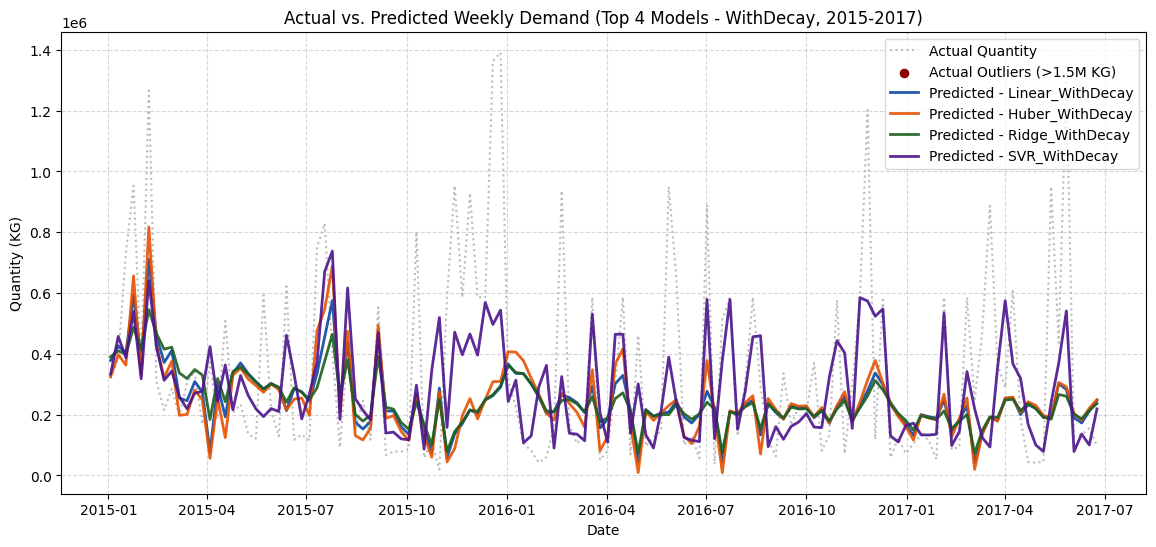

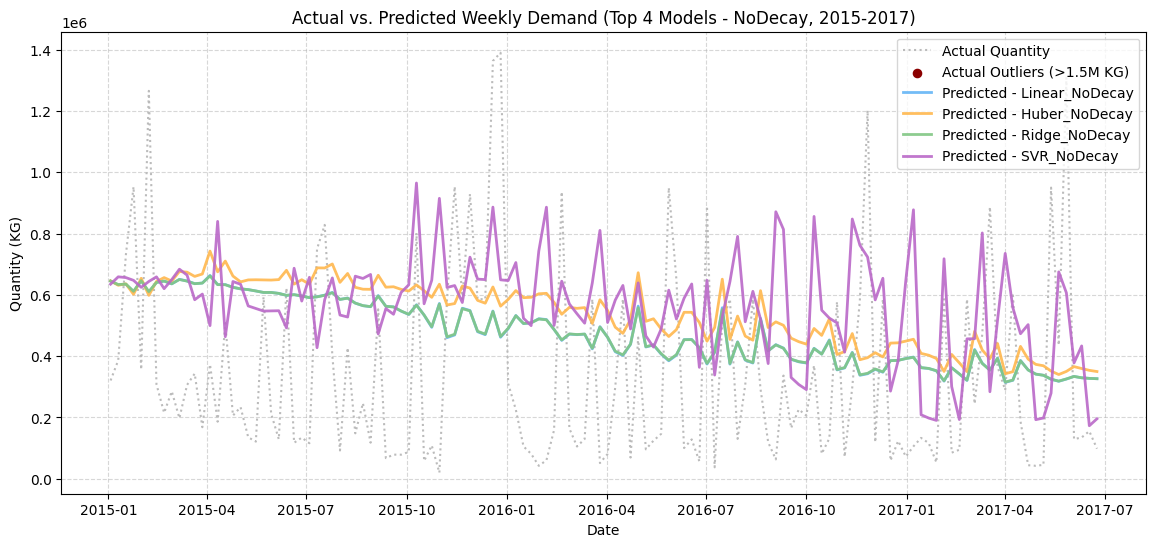

In [85]:
# Plot rolling predictions vs actuals for top 4 models (2015-2017 only)
plot_dates = pd.to_datetime(dates)
filter_2015 = (plot_dates >= '2015-01-01') & (plot_dates <= '2017-12-31')

filtered_plot_dates = plot_dates[filter_2015]
filtered_actual_qs = np.array(actual_qs)[filter_2015]

color_pairs = {
    'Linear': ('#0d47a1', '#64b5f6'),  # Blue
    'Huber': ('#e65100', '#ffb74d'),   # Orange
    'Ridge': ('#1b5e20', '#81c784'),   # Green
    'SVR': ('#4a148c', '#ba68c8'),     # Purple
}

# Identify outliers on actual quantity (> 2e6 KG)
outliers_mask = filtered_actual_qs > 1.5e6
outlier_dates = filtered_plot_dates[outliers_mask]
outlier_qs = filtered_actual_qs[outliers_mask]

# Plot 1a: WithDecay
plt.figure(figsize=(14, 6))
# Actual quantity: light and dotted
plt.plot(filtered_plot_dates, filtered_actual_qs, color='#bbbbbb', linestyle=':', label='Actual Quantity', linewidth=1.5)
# Outliers: marked with dark red markers
plt.scatter(outlier_dates, outlier_qs, color='darkred', marker='o', s=35, label='Actual Outliers (>1.5M KG)', zorder=5)
for base_name, (c_decay, _) in color_pairs.items():
    wd_name = base_name + '_WithDecay'
    if wd_name in results:
        preds_wd = np.array([p['pred'] for p in results[wd_name]])[filter_2015]
        # Predictions: dark solid
        plt.plot(filtered_plot_dates, preds_wd, label=f'Predicted - {wd_name}', color=c_decay, alpha=0.9, linestyle='-', linewidth=2.0)
plt.title('Actual vs. Predicted Weekly Demand (Top 4 Models - WithDecay, 2015-2017)')
plt.xlabel('Date')
plt.ylabel('Quantity (KG)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Plot 1b: NoDecay
if not RUN_DECAY_ONLY:
    plt.figure(figsize=(14, 6))
    # Actual quantity: light and dotted
    plt.plot(filtered_plot_dates, filtered_actual_qs, color='#bbbbbb', linestyle=':', label='Actual Quantity', linewidth=1.5)
    # Outliers: marked with dark red markers
    plt.scatter(outlier_dates, outlier_qs, color='darkred', marker='o', s=35, label='Actual Outliers (>1.5M KG)', zorder=5)
    for base_name, (_, c_nodecay) in color_pairs.items():
        nd_name = base_name + '_NoDecay'
        if nd_name in results:
            preds_nd = np.array([p['pred'] for p in results[nd_name]])[filter_2015]
            # Predictions: solid line using the model color
            plt.plot(filtered_plot_dates, preds_nd, label=f'Predicted - {nd_name}', color=c_nodecay, alpha=0.9, linestyle='-', linewidth=2.0)
    plt.title('Actual vs. Predicted Weekly Demand (Top 4 Models - NoDecay, 2015-2017)')
    plt.xlabel('Date')
    plt.ylabel('Quantity (KG)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### Chart 1: Quantity-Price Graph (Testing Backtest Predictions)

This plot shows the relationship between unit prices and predicted quantities across the **rolling test set weeks**. The range is limited to +/- 30% of the current price ($[25.33, 47.05]$ INR/KG).

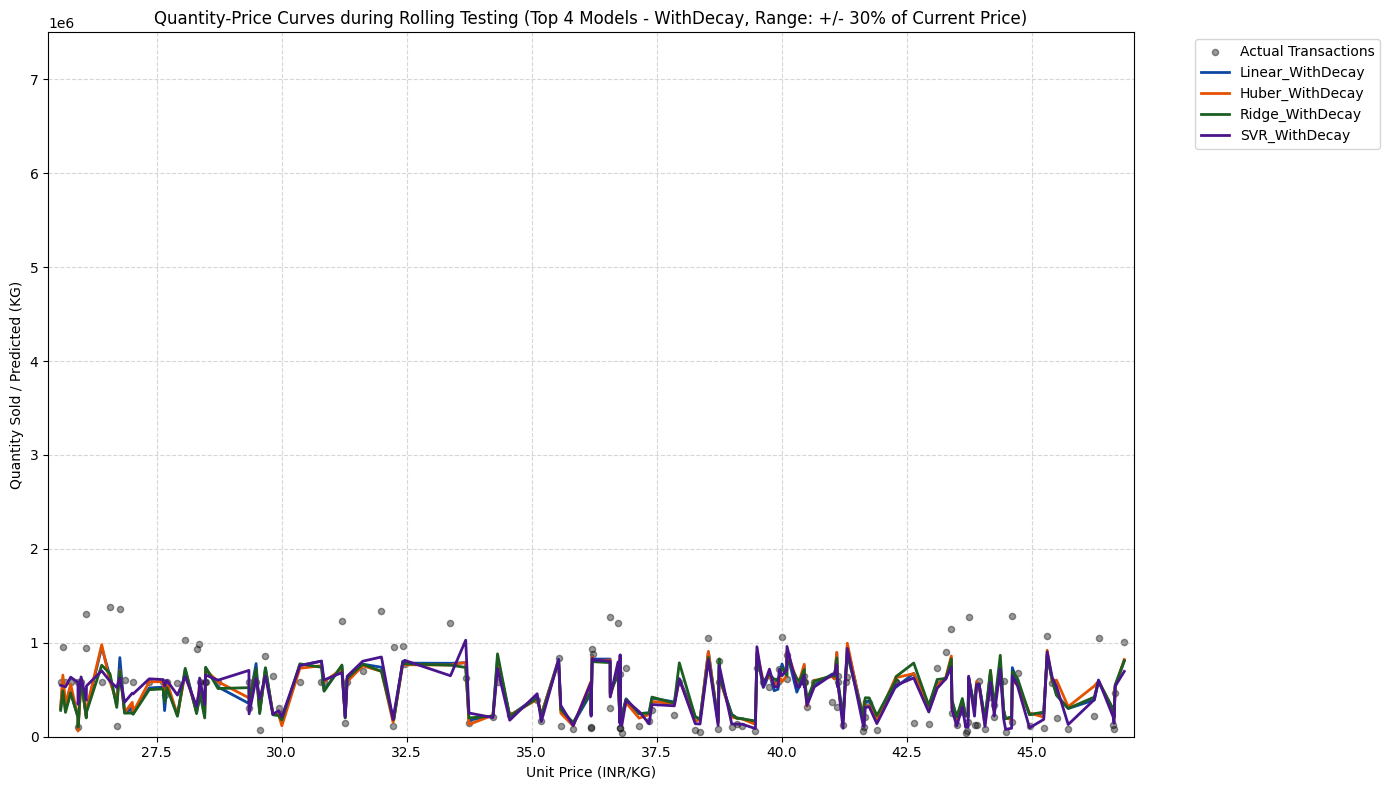

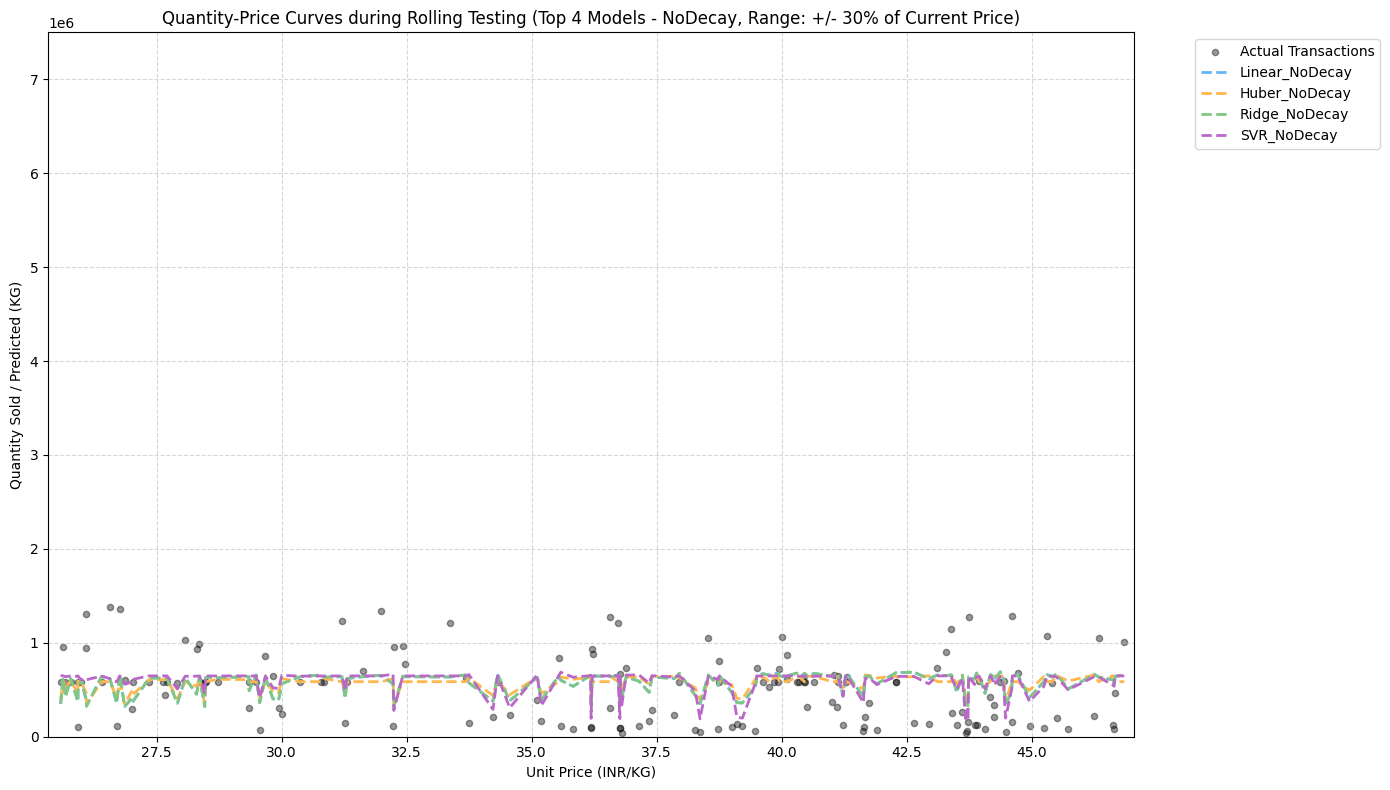

In [86]:
prices = np.array(actual_ps)
p_current = df['unit_price'].iloc[-1]
p_min = p_current * 0.7
p_max = p_current * 1.3

filter_idx = (prices >= p_min) & (prices <= p_max)
filtered_prices = prices[filter_idx]
filtered_actual_qs = actual_qs[filter_idx]
sorted_idx = np.argsort(filtered_prices)

# Chart 1a: WithDecay
plt.figure(figsize=(14, 8))
plt.scatter(filtered_prices, filtered_actual_qs, color='black', alpha=0.4, label='Actual Transactions', s=20)
for base_name, (c_decay, _) in color_pairs.items():
    wd_name = base_name + '_WithDecay'
    if wd_name in results:
        preds_wd = np.array([p['pred'] for p in results[wd_name]])[filter_idx]
        plt.plot(filtered_prices[sorted_idx], preds_wd[sorted_idx], label=wd_name, color=c_decay, linewidth=2.0)
plt.title('Quantity-Price Curves during Rolling Testing (Top 4 Models - WithDecay, Range: +/- 30% of Current Price)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Quantity Sold / Predicted (KG)')
plt.xlim(p_min, p_max)
plt.ylim(0, 7.5e6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Chart 1b: NoDecay
if not RUN_DECAY_ONLY:
    plt.figure(figsize=(14, 8))
    plt.scatter(filtered_prices, filtered_actual_qs, color='black', alpha=0.4, label='Actual Transactions', s=20)
    for base_name, (_, c_nodecay) in color_pairs.items():
        nd_name = base_name + '_NoDecay'
        if nd_name in results:
            preds_nd = np.array([p['pred'] for p in results[nd_name]])[filter_idx]
            plt.plot(filtered_prices[sorted_idx], preds_nd[sorted_idx], label=nd_name, color=c_nodecay, linewidth=2.0, linestyle='--')
    plt.title('Quantity-Price Curves during Rolling Testing (Top 4 Models - NoDecay, Range: +/- 30% of Current Price)')
    plt.xlabel('Unit Price (INR/KG)')
    plt.ylabel('Quantity Sold / Predicted (KG)')
    plt.xlim(p_min, p_max)
    plt.ylim(0, 7.5e6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Chart 2: Quantity-Price Graph (Last Estimation / Final Window)

Here we fit the models on the **final training window** (the last 200 weeks of the dataset) and project their demand curves across a wide range of pricing scenarios (30% below to 30% above the current price).

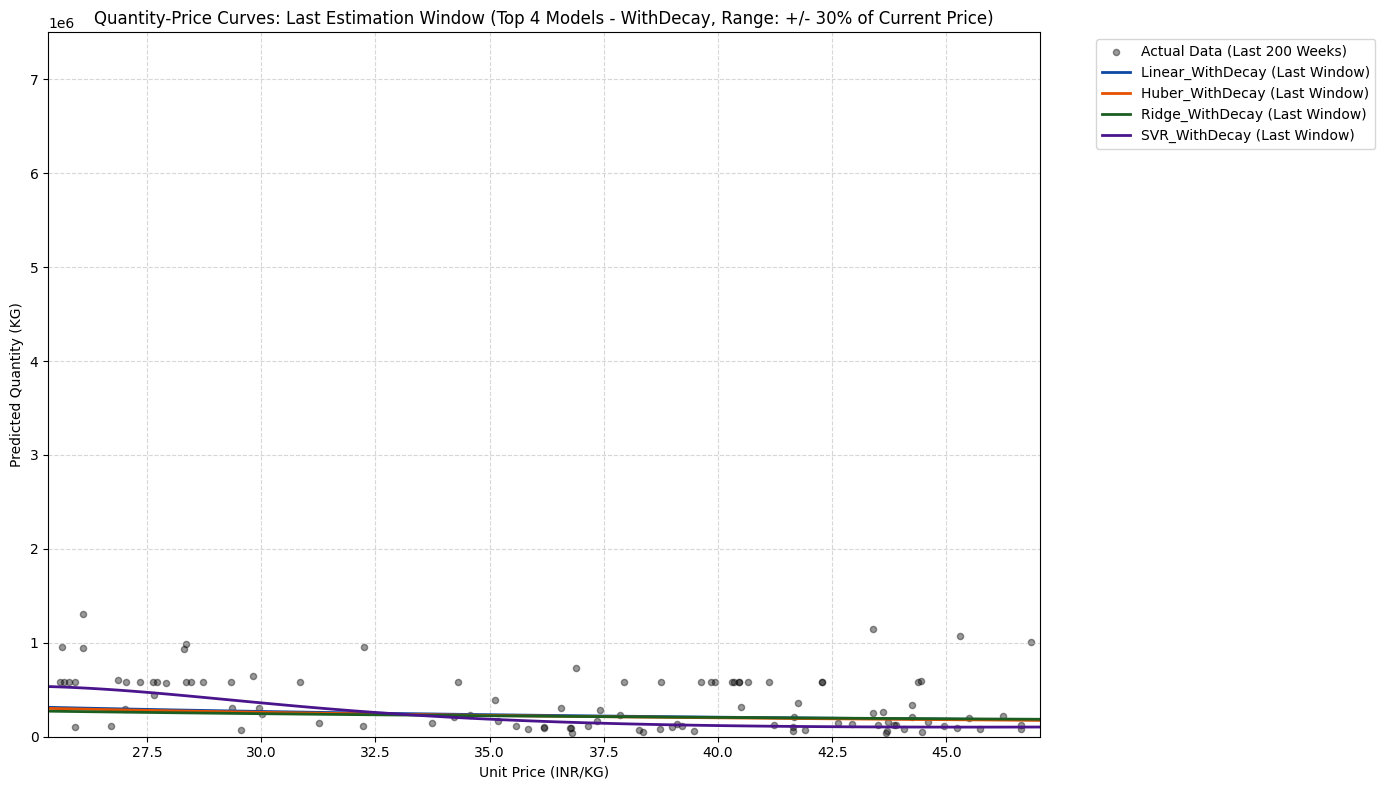

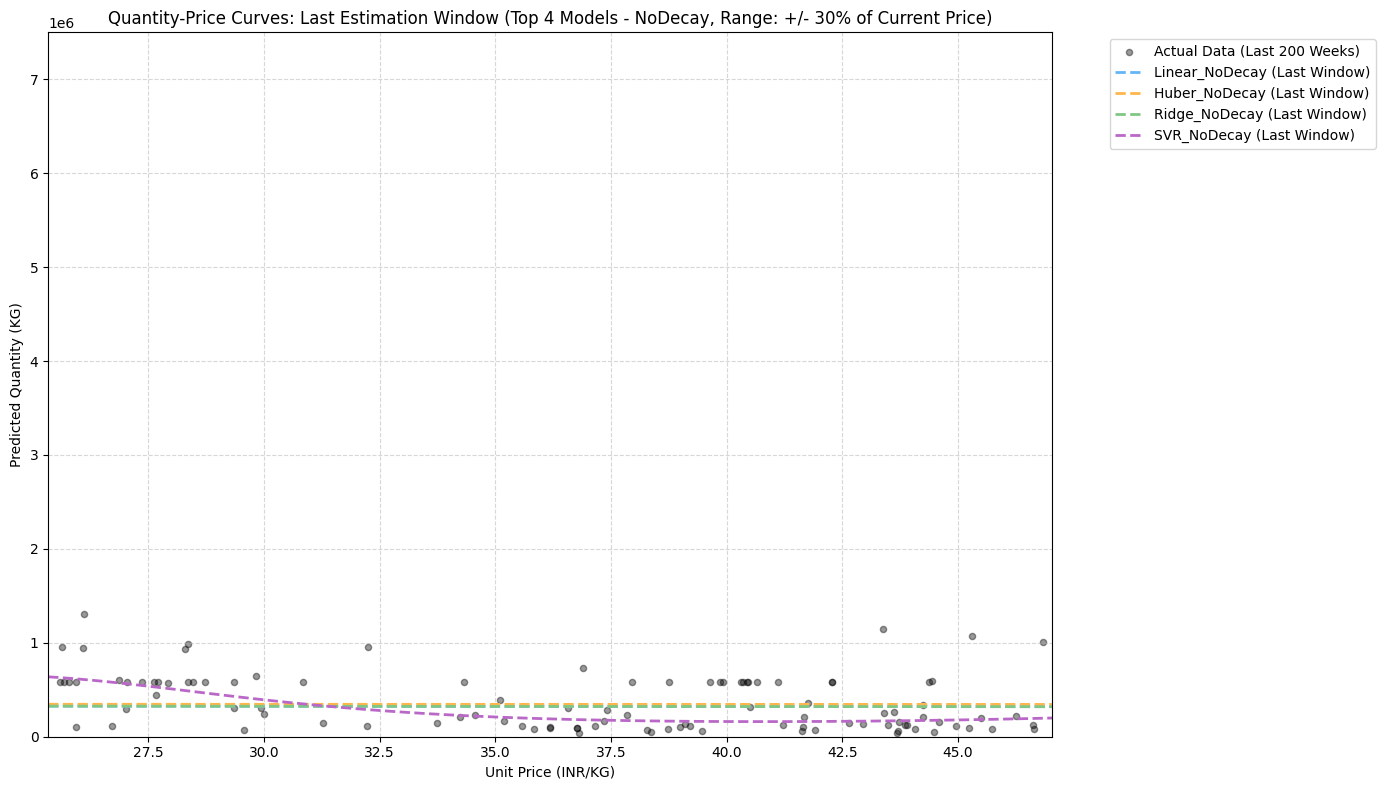

In [87]:
final_train_slice = df.iloc[-200:]
test_prices_range = np.linspace(p_min, p_max, 100)
hist_in_range = final_train_slice[(final_train_slice['unit_price'] >= p_min) & (final_train_slice['unit_price'] <= p_max)]

# Chart 2a: WithDecay
plt.figure(figsize=(14, 8))
plt.scatter(hist_in_range['unit_price'], hist_in_range['units_sold'], color='black', alpha=0.4, label='Actual Data (Last 200 Weeks)', s=20)
for base_name, (c_decay, _) in color_pairs.items():
    wd_name = base_name + '_WithDecay'
    if wd_name in results:
        q_wd = []
        for p in test_prices_range:
            _, q_wd_p = run_model(base_name, final_train_slice, p, use_decay=True)
            q_wd.append(q_wd_p)
        plt.plot(test_prices_range, q_wd, label=f"{wd_name} (Last Window)", color=c_decay, linewidth=2.0)
plt.title('Quantity-Price Curves: Last Estimation Window (Top 4 Models - WithDecay, Range: +/- 30% of Current Price)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Predicted Quantity (KG)')
plt.xlim(p_min, p_max)
plt.ylim(0, 7.5e6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Chart 2b: NoDecay
if not RUN_DECAY_ONLY:
    plt.figure(figsize=(14, 8))
    plt.scatter(hist_in_range['unit_price'], hist_in_range['units_sold'], color='black', alpha=0.4, label='Actual Data (Last 200 Weeks)', s=20)
    for base_name, (_, c_nodecay) in color_pairs.items():
        nd_name = base_name + '_NoDecay'
        if nd_name in results:
            q_nd = []
            for p in test_prices_range:
                _, q_nd_p = run_model(base_name, final_train_slice, p, use_decay=False)
                q_nd.append(q_nd_p)
            plt.plot(test_prices_range, q_nd, label=f"{nd_name} (Last Window)", color=c_nodecay, linewidth=2.0, linestyle='--')
    plt.title('Quantity-Price Curves: Last Estimation Window (Top 4 Models - NoDecay, Range: +/- 30% of Current Price)')
    plt.xlabel('Unit Price (INR/KG)')
    plt.ylabel('Predicted Quantity (KG)')
    plt.xlim(p_min, p_max)
    plt.ylim(0, 7.5e6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()